<a href="https://colab.research.google.com/github/adljna/ProjectA-Group3-KematianAliKhamenei/blob/main/Content%20Scraping%20%26%20Preprocessing/Antara/2_Antara_PreprocessingNews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preprocessing Indonesian Text

**(1) Instalasi Library**

Bagian ini berisi instalasi semua library Python yang dibutuhkan untuk scraping, preprocessing teks, POS tagging, dan analisis sentimen.

In [ ]:
# Library untuk scraping dan manipulasi data
!pip install beautifulsoup4 requests pandas

# Library untuk NLP: polyglot (untuk deteksi bahasa), deep-translator (untuk terjemahan), Sastrawi (untuk stemming), Stanza (untuk POS Tagging)
!pip install polyglot icu pycld2 pyicu morfessor
!pip install deep-translator
!pip install Sastrawi
!pip install stanza

# Library tambahan untuk NLP (NLTK) dan visualisasi (wordcloud)
!pip install nltk
!pip install wordcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.3/126.3 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.2/268.2 kB 10.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 61.5 MB/s eta 0:00:00
  Created wheel for polyglot: filename=polyglot-16.7.4-py2.py3-none-any.whl size=52563 sha256=f71e374bee0f5fd3d0b8e7b50f5d1f637b4d6490e152ca3cd3d18b78e8cc08e7
  Stored in directory: /root/.cache/pip/wheels/c7/5e/28/47349211ec1f91379f41ed10bc2520f7071ecfb6cbe182f6fe
  Created wheel for pyicu: filename=pyicu-2.16.2-cp312-cp312-linux_x86_64.whl size=2720233 sha256=e3c494f9288746e9a84e86bfd0b6420ea4d621f9adccdef5a3c276b27f01375e
  Stored in directory: /root/.cache/pip/wheels/25/f3/cd/4923c874cedf8cdb860803

**(2) Impor Library**

Bagian ini mengimpor semua modul dan fungsi yang diperlukan dari library yang telah diinstal. Import dikelompokkan berdasarkan fungsinya.

In [ ]:
# Standard Library
import io
import string
import re
import time
from collections import defaultdict, Counter

# Data Handling
import pandas as pd
import numpy as np

# Web Scraping
import requests
from bs4 import BeautifulSoup
from google.colab import files

# Natural Language Processing (NLP) - NLTK
import nltk
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

# Natural Language Processing (NLP) - Sastrawi (Stemming)
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Natural Language Processing (NLP) - Stanza (POS Tagging)
import stanza

# Sentiment Analysis
from textblob import TextBlob
from deep_translator import GoogleTranslator

# Visualization
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [ ]:
# Download NLTK data (if not already downloaded)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

**(3) Data Scraping**

Bagian ini bertanggung jawab untuk mengunggah file CSV yang berisi tautan (links) dan melakukan scraping konten artikel dari tautan tersebut. Menggunakan `requests` dan `BeautifulSoup`.

In [ ]:
from google.colab import files

# Upload the CSV file
uploaded = files.upload()
filename = list(uploaded.keys())[0]

Saving Tugas 1A Kelompok 3 - Antara.csv to Tugas 1A Kelompok 3 - Antara (1).csv


In [ ]:
import io
try:
    # Modified: Changed from pd.read_excel to pd.read_csv and removed sheet_name
    links_df = pd.read_csv(io.BytesIO(uploaded[filename]))

    if 'Link' in links_df.columns:
        urls = links_df['Link'].tolist()
        print(f"Successfully loaded {len(urls)} URLs from '{filename}'.")
    else:
        print("Error: 'link' column not found in the uploaded file. Please check your CSV file.")
        urls = [] # Set urls to empty if column not found
except FileNotFoundError:
    print("Error: Uploaded file not found. Please upload the CSV file.")
    urls = [] # Set urls to empty if file not found
except Exception as e:
    print(f"An error occurred while reading the file: {e}")
    urls = []
# --------------------------------------------------

# Function to scrape content from a URL
def scrape_content(url):
    try:
        response = requests.get(url)
        if response.status_code == 200:
            soup = BeautifulSoup(response.content, 'html.parser')

            # Extract the title of the article
            title = soup.find('title').text

            # Extract the article's content
            paragraphs = soup.find_all('p')
            content = "\n".join([para.text for para in paragraphs])

            return {
                "url": url,
                "title": title,
                "content": content
            }

        else:
            return {
                "url": url,
                "title": None,
                "content": None,
                "error": f"Failed to fetch page, status code: {response.status_code}"
            }
    except Exception as e:
        return {
            "url": url,
            "title": None,
            "content": None,
            "error": str(e)
        }

# Scrape each URL and store the results in a list of dictionaries
data = []
if urls: # Only proceed if URLs were successfully loaded
    for url in urls:
        result = scrape_content(url)
        data.append(result)
else:
    print("No URLs to scrape. Please check your uploaded CSV file and ensure it has a 'link' column.")

# Create a pandas DataFrame from the list of dictionaries
df_article = pd.DataFrame(data)

# Display the DataFrame
df_article.head()

# Save the DataFrame to a CSV file (optional)
df_article.to_csv('scraped_articles.csv', index=False)

Successfully loaded 100 URLs from 'Tugas 1A Kelompok 3 - Antara (1).csv'.


In [ ]:
# Function to scrape content from a URL
def scrape_content(url):
    try:
        # Add a User-Agent header to mimic a browser and avoid 403 Forbidden errors
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
        response = requests.get(url, headers=headers)
        if response.status_code == 200:
            soup = BeautifulSoup(response.content, 'html.parser')

            # Extract the title of the article
            title = soup.find('title').text if soup.find('title') else 'No Title Found'

            # Extract the article's content
            # Try to find common article body tags first
            article_content_div = soup.find('article') or soup.find('div', class_='article-content') or soup.find('div', class_='detail_text')

            if article_content_div:
                paragraphs = article_content_div.find_all('p')
            else:
                paragraphs = soup.find_all('p')

            content = "\n".join([para.text for para in paragraphs])

            return {
                "url": url,
                "title": title,
                "content": content
            }

        else:
            return {
                "url": url,
                "title": None,
                "content": None,
                "error": f"Failed to fetch page, status code: {response.status_code}"
            }
    except Exception as e:
        return {
            "url": url,
            "title": None,
            "content": None,
            "error": str(e)
        }

**(4) Data Preprocessing**

Bagian ini membersihkan dan mempersiapkan teks dari artikel yang discrape untuk analisis lebih lanjut. Langkah-langkah meliputi:
- **`clean_text`**: Menghilangkan URL, mention, angka, tanda baca, dan spasi berlebih.
- **`tokenize_text`**: Memecah teks menjadi token kata.
- **`remove_stopwords`**: Menghapus kata-kata umum (stopwords) dalam bahasa Indonesia.
- **`stem_text`**: Melakukan stemming untuk mengembalikan kata ke bentuk dasar menggunakan `Sastrawi`.
- **Deteksi Bahasa**: Menggunakan `polyglot` untuk mendeteksi bahasa teks.

Library yang digunakan: `re`, `string`, `nltk`, `Sastrawi`, `polyglot`.

In [ ]:
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

def clean_text(text):
    if not isinstance(text, str): # Handle non-string input, e.g., None
        return ""
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'@\w+', '', text) # Remove mentions
    text = re.sub(r'\d+', '', text) # Remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation)) # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    return text

def tokenize_text(text):
    if not isinstance(text, str): # Handle non-string input
        return []
    return word_tokenize(text)

# Get Indonesian stopwords
list_stopwords = nltk.corpus.stopwords.words('indonesian')

def remove_stopwords(tokens, stopwords_list):
    return [word for word in tokens if word not in stopwords_list and word.strip() != '']

def stem_text(tokens):
    return [stemmer.stem(word) for word in tokens]

In [ ]:
# Terapkan cleaning dan tokenisasi
df_article['text_cleaned'] = df_article['content'].fillna('').apply(clean_text)
df_article['tokens'] = df_article['text_cleaned'].apply(tokenize_text)

# Hapus stopwords
df_article['tokens_no_stop'] = df_article['tokens'].apply(lambda x: remove_stopwords(x, list_stopwords))

# Lakukan stemming
df_article['tokens_stemmed'] = df_article['tokens_no_stop'].apply(stem_text)

# Gabungkan kembali token yang sudah di-stem menjadi string
df_article['text_final'] = df_article['tokens_stemmed'].apply(lambda x: ' '.join(x))

print("DataFrame setelah Cleaning, Tokenisasi, Stopword Removal, dan Stemming:")
print(df_article[['content', 'text_cleaned', 'tokens', 'tokens_no_stop', 'tokens_stemmed', 'text_final']].head())

# Language Detection (using Polyglot for demonstration, Stanza for POS Tagging)
print("\nDeteksi Bahasa pada Konten Asli:")
for index, row in df_article.head(5).iterrows(): # Check first 5 rows for language
    try:
        text = Text(row['content'] if pd.notna(row['content']) else "")
        if text.language.code:
            print(f"Row {index}: Language Detected: Code={text.language.code}, Name={text.language.name}")
        else:
            print(f"Row {index}: Language detection failed.")
    except Exception as e:
        print(f"Row {index}: Error during language detection - {e}")

DataFrame setelah Cleaning, Tokenisasi, Stopword Removal, dan Stemming:
                                             content  \
0  Washington (ANTARA) - Presiden Amerika Serikat...   
1  Doha (ANTARA) - Iran tidak akan menyetujui gen...   
2  Teheran (ANTARA) - Iran tidak akan pernah meny...   
3  Doha (ANTARA) - Juru Bicara Kementerian Luar N...   
4  Teheran (ANTARA) - Warga Iran pada Senin (9/3)...   

                                        text_cleaned  \
0  washington antara presiden amerika serikat don...   
1  doha antara iran tidak akan menyetujui gencata...   
2  teheran antara iran tidak akan pernah menyetuj...   
3  doha antara juru bicara kementerian luar neger...   
4  teheran antara warga iran pada senin menghadir...   

                                              tokens  \
0  [washington, antara, presiden, amerika, serika...   
1  [doha, antara, iran, tidak, akan, menyetujui, ...   
2  [teheran, antara, iran, tidak, akan, pernah, m...   
3  [doha, antara, juru, bicara

**(5) Analisis Sentimen**

Bagian ini menganalisis sentimen dari teks artikel. Karena `TextBlob` hanya mendukung bahasa Inggris, teks bahasa Indonesia akan diterjemahkan terlebih dahulu ke bahasa Inggris menggunakan `GoogleTranslator`, kemudian dianalisis polaritasnya. Teks panjang juga ditangani dengan memecahnya menjadi beberapa bagian untuk menghindari batasan API.

Library yang digunakan: `TextBlob`, `deep_translator`.

In [ ]:
def analyze_long_text_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return pd.Series([None, None])

    # If text is short, directly process
    if len(text) < 4500:
        try:
            translated_text = GoogleTranslator(source='id', target='en').translate(text)
            blob = TextBlob(translated_text)
            return pd.Series([blob.sentiment.polarity, blob.sentiment.subjectivity])
        except Exception as e:
            print(f"Error processing short text: {e}")
            return pd.Series([None, None])

    # If text is long, chunk it
    else:
        try:
            max_chunk_size = 4500
            chunks = [text[i:i+max_chunk_size] for i in range(0, len(text), max_chunk_size)]

            translated_chunks = []
            for i, chunk in enumerate(chunks):
                # Add a small delay to avoid hitting API rate limits
                if i > 0: # Only sleep for subsequent chunks
                    time.sleep(0.5)
                translated_chunks.append(
                    GoogleTranslator(source='id', target='en').translate(chunk)
                )

            # Combine all translated chunks
            full_translated_text = ' '.join(translated_chunks)

            # Analyze sentiment of the full translated text
            blob = TextBlob(full_translated_text)
            return pd.Series([blob.sentiment.polarity, blob.sentiment.subjectivity])

        except Exception as e:
            print(f"Error processing long text: {e}")
            return pd.Series([None, None])

def get_sentiment_label_from_polarity(polarity):
    if polarity is None:
        return 'Undefined'
    elif polarity > 0.05:
        return 'Positive'
    elif polarity < -0.05:
        return 'Negative'
    else:
        return 'Netral'

# Apply the sentiment analysis function to the 'text_final' column
df_article[['polarity', 'subjectivity']] = df_article['text_final'].apply(analyze_long_text_sentiment)

# Fill any NaN polarity values with 0 before labeling
df_article['polarity'].fillna(0, inplace=True)

# Create sentiment labels
df_article['sentiment_label'] = df_article['polarity'].apply(get_sentiment_label_from_polarity)

print("\nDataFrame dengan hasil sentimen:")
print(df_article[['content', 'text_final', 'polarity', 'subjectivity', 'sentiment_label']].head())


DataFrame dengan hasil sentimen:
                                             content  \
0  Washington (ANTARA) - Presiden Amerika Serikat...   
1  Doha (ANTARA) - Iran tidak akan menyetujui gen...   
2  Teheran (ANTARA) - Iran tidak akan pernah meny...   
3  Doha (ANTARA) - Juru Bicara Kementerian Luar N...   
4  Teheran (ANTARA) - Warga Iran pada Senin (9/3)...   

                                          text_final  polarity  subjectivity  \
0  washington presiden amerika serikat donald tru...  0.080080      0.372059   
1  doha iran tuju gencat senjata serang ajar piki...  0.100000      0.233333   
2  teheran iran tuju gencat senjata serang ajar p...  0.000833      0.312500   
3  doha juru bicara menteri negeri qatar majed al...  0.070391      0.308018   
4  teheran warga iran senin hadir temu akbar penj...  0.227778      0.469444   

  sentiment_label  
0        Positive  
1        Positive  
2          Netral  
3        Positive  
4        Positive  


/tmp/ipykernel_18947/502083443.py:55: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_article['polarity'].fillna(0, inplace=True)


**(6) Visualisasi (Word Cloud)**

Bagian ini membuat visualisasi Word Cloud untuk kata-kata yang paling sering muncul dalam artikel dengan sentimen Positif dan Negatif. Ini membantu dalam memahami topik yang terkait dengan masing-masing sentimen.

Library yang digunakan: `matplotlib.pyplot`, `wordcloud`.


Jumlah artikel Positif: 38
Jumlah artikel Negatif: 17


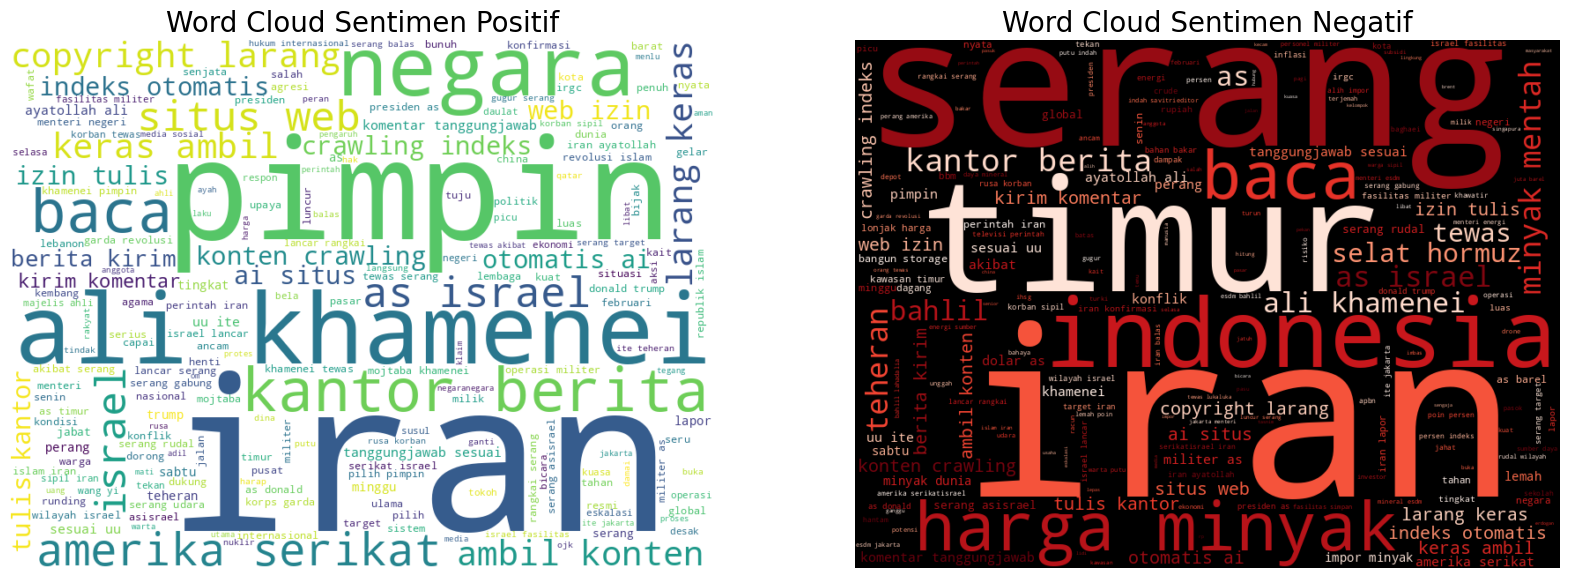

In [ ]:
positive_articles_df = df_article[df_article['sentiment_label'] == 'Positive']
negative_articles_df = df_article[df_article['sentiment_label'] == 'Negative']

print(f"\nJumlah artikel Positif: {len(positive_articles_df)}")
print(f"Jumlah artikel Negatif: {len(negative_articles_df)}")

positive_text = ' '.join(positive_articles_df['text_final'])
negative_text = ' '.join(negative_articles_df['text_final'])

plt.figure(figsize=(20, 10))

# Word Cloud Positif
if positive_text:
    plt.subplot(1, 2, 1)
    wordcloud_positive = WordCloud(
        stopwords=list_stopwords,
        width=800,
        height=600,
        background_color='white',
        colormap='viridis'
    ).generate(positive_text)
    plt.imshow(wordcloud_positive, interpolation='bilinear')
    plt.title('Word Cloud Sentimen Positif', fontsize=20)
    plt.axis('off')
else:
    print("Tidak ada teks positif untuk Word Cloud.")

# Word Cloud Negatif
if negative_text:
    plt.subplot(1, 2, 2)
    wordcloud_negative = WordCloud(
        stopwords=list_stopwords,
        width=800,
        height=600,
        background_color='black',
        colormap='Reds'
    ).generate(negative_text)
    plt.imshow(wordcloud_negative, interpolation='bilinear')
    plt.title('Word Cloud Sentimen Negatif', fontsize=20)
    plt.axis('off')
else:
    print("Tidak ada teks negatif untuk Word Cloud.")

plt.show()

**(7) Ekspor Hasil**

Bagian ini menyimpan DataFrame akhir yang berisi semua data, hasil preprocessing, dan sentimen ke dalam file CSV.

In [ ]:
df_article.to_csv(r'analyzed_articles.csv', index=False)
print("Hasil analisis disimpan ke 'analyzed_articles.csv'")

Hasil analisis disimpan ke 'analyzed_articles.csv'
